# Actividad 3 — EDA · MIDAGRI

**Objetivo:** Analizar la produccion de limon para justificar la seleccion del cultivo, los departamentos a incluir en el modelo y entender la estacionalidad y relacion precio-produccion.

**Entrada:** `sources/midagri/Sisagri_2016_2025.xlsx` (ambas hojas)
**Salidas:** Graficos en `pipeline/output/03_eda/act03_midagri_*.png`


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos MIDAGRI


In [2]:
xl = pd.ExcelFile(SOURCES['midagri'])
dfs = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m = pd.concat(dfs, ignore_index=True)

# Filtrar solo limon para el EDA
df_limon = df_m[df_m['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
df_limon['fecha'] = pd.to_datetime(
    df_limon['anho'].astype(str) + '-' + df_limon['mes'].astype(str).str.zfill(2) + '-01'
)
print(f'Dataset completo MIDAGRI: {df_m.shape}')
print(f'Solo LIMON: {df_limon.shape}')
print(f'Departamentos con limon: {df_limon["Dpto"].nunique()}')
print(f'Rango temporal: {df_limon["fecha"].min().date()} -> {df_limon["fecha"].max().date()}')


Dataset completo MIDAGRI: (1596748, 10)
Solo LIMON: (40284, 11)
Departamentos con limon: 23
Rango temporal: 2016-01-01 -> 2025-08-01


## 3.1 Grafico 1 — Produccion de limon por departamento


Departamentos que concentran el 80% de la produccion: ['PIURA', 'TUMBES', 'LAMBAYEQUE']
Porcentaje acumulado: 82.9%



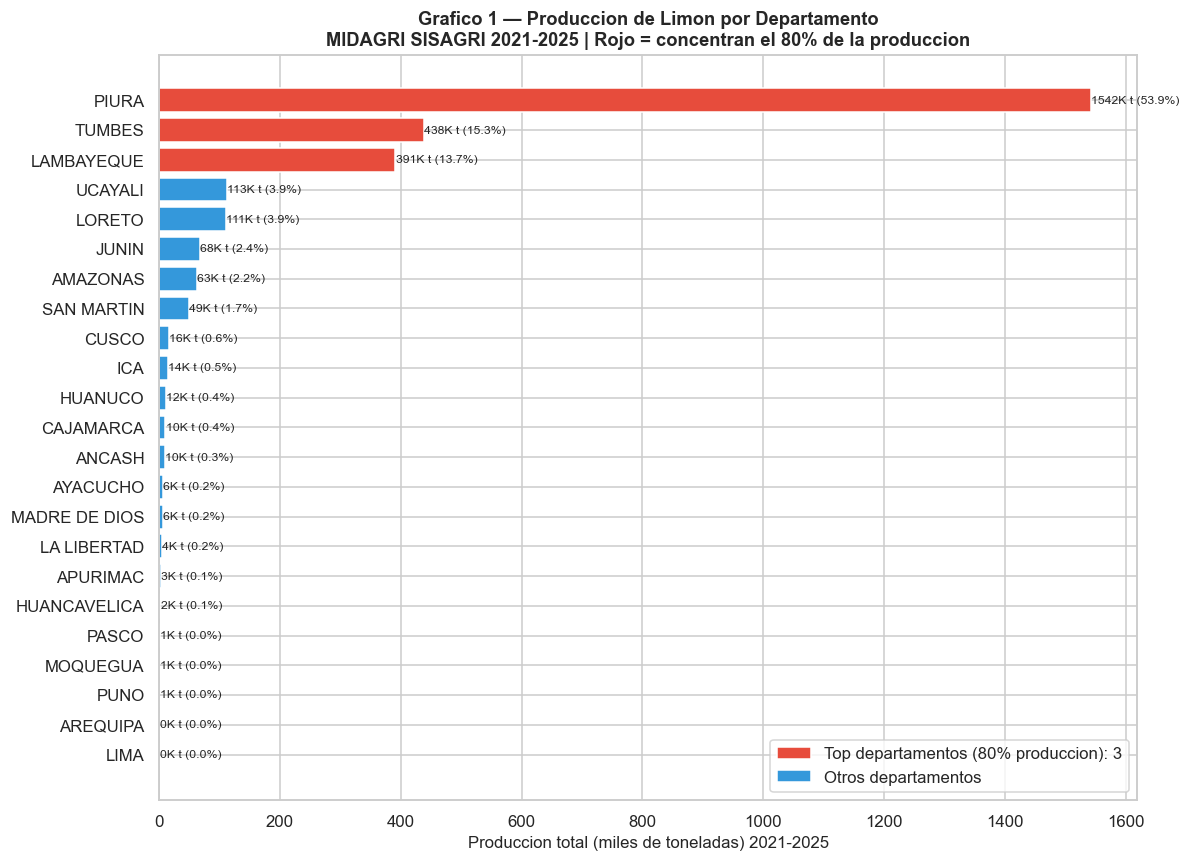

Guardado: pipeline/output/03_eda/act03_midagri_g1_prod_dpto.png


In [3]:
prod_dpto = (
    df_limon.groupby('Dpto')['PRODUCCION(t)']
    .sum().sort_values(ascending=True)
)
total = prod_dpto.sum()
prod_dpto_pct = (prod_dpto / total * 100).round(1)

# Regla de Pareto: departamentos que acumulan el 80%
prod_desc = prod_dpto.sort_values(ascending=False)
acum = 0
dptos_80 = []
for d, v in prod_desc.items():
    acum += v / total * 100
    dptos_80.append(d)
    if acum >= 80:
        break
print(f'Departamentos que concentran el 80% de la produccion: {dptos_80}')
print(f'Porcentaje acumulado: {acum:.1f}%')
print()

colors_dpto = ['#e74c3c' if d in dptos_80 else '#3498db' for d in prod_dpto.index]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(prod_dpto.index, prod_dpto.values / 1e3, color=colors_dpto, edgecolor='white')
for bar, val, pct in zip(bars, prod_dpto.values, prod_dpto_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val/1e3:.0f}K t ({pct}%)', va='center', fontsize=8)
ax.set_xlabel('Produccion total (miles de toneladas) 2021-2025', fontsize=11)
ax.set_title('Grafico 1 — Produccion de Limon por Departamento\n'
             'MIDAGRI SISAGRI 2021-2025 | Rojo = concentran el 80% de la produccion',
             fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', label=f'Top departamentos (80% produccion): {len(dptos_80)}'),
    Patch(facecolor='#3498db', label='Otros departamentos')
], loc='lower right')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g1_prod_dpto.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La produccion total de limon por departamento 2021-2025. Los departamentos en rojo concentran el 80% de la produccion nacional (regla de Pareto).

**Implicacion para el pipeline:** El modelo se entrenara priorizando estos departamentos. Los departamentos con produccion marginal pueden generar ruido en el modelo y se evaluara su inclusion en la Actividad 5.

**Implicacion para el modelo:** Concentrar el entrenamiento en los departamentos de mayor produccion garantiza que el LSTM-Attention aprenda patrones representativos del mercado nacional de limon, no de zonas marginales con series temporales muy cortas o irregulares.


## 3.2 Grafico 2 — Serie temporal de produccion mensual


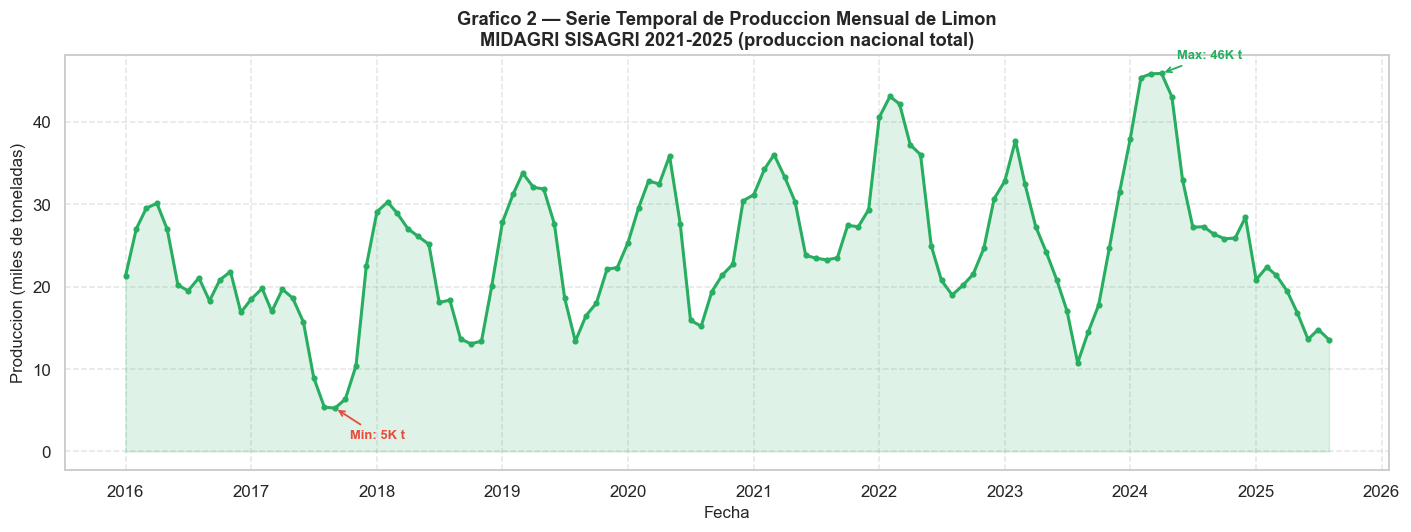

Guardado: pipeline/output/03_eda/act03_midagri_g2_serie_temporal.png
Produccion media mensual: 24.7K t
Coeficiente de variacion: 35.0%


In [4]:
serie = df_limon.groupby('fecha')['PRODUCCION(t)'].sum().reset_index()
serie = serie.sort_values('fecha')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie['fecha'], serie['PRODUCCION(t)'] / 1e3,
        color='#27ae60', linewidth=2, marker='o', markersize=3)
ax.fill_between(serie['fecha'], serie['PRODUCCION(t)'] / 1e3, alpha=0.15, color='#27ae60')

# Marcar minimos y maximos
idx_max = serie['PRODUCCION(t)'].idxmax()
idx_min = serie['PRODUCCION(t)'].idxmin()
ax.annotate(f'Max: {serie.loc[idx_max,"PRODUCCION(t)"]/1e3:.0f}K t',
            xy=(serie.loc[idx_max,'fecha'], serie.loc[idx_max,'PRODUCCION(t)']/1e3),
            xytext=(10, 10), textcoords='offset points',
            fontsize=8.5, color='#27ae60', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2))
ax.annotate(f'Min: {serie.loc[idx_min,"PRODUCCION(t)"]/1e3:.0f}K t',
            xy=(serie.loc[idx_min,'fecha'], serie.loc[idx_min,'PRODUCCION(t)']/1e3),
            xytext=(10, -20), textcoords='offset points',
            fontsize=8.5, color='#e74c3c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2))

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Produccion (miles de toneladas)', fontsize=11)
ax.set_title('Grafico 2 — Serie Temporal de Produccion Mensual de Limon\n'
             'MIDAGRI SISAGRI 2021-2025 (produccion nacional total)', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g2_serie_temporal.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Produccion media mensual: {serie["PRODUCCION(t)"].mean()/1e3:.1f}K t')
print(f'Coeficiente de variacion: {serie["PRODUCCION(t)"].std()/serie["PRODUCCION(t)"].mean()*100:.1f}%')


### Interpretacion

**Que muestra:** La evolucion mensual de la produccion total de limon en el Peru 2021-2025. Se identifican el mes de mayor y menor produccion, y si hay tendencia creciente o decreciente.

**Implicacion para el pipeline:** Los meses con caidas bruscas de produccion son candidatos a investigar en la Actividad 4 (pueden ser datos faltantes o eventos reales como el Nino Costero). El coeficiente de variacion indica que tan variable es la produccion mes a mes.

**Implicacion para el modelo:** La estacionalidad visible en la serie confirma que el LSTM-Attention necesita capturar patrones temporales ciclicos. La variable objetivo del modelo es esta serie de produccion mensual.


## 3.3 Grafico 3 — Distribucion de precios en chacra


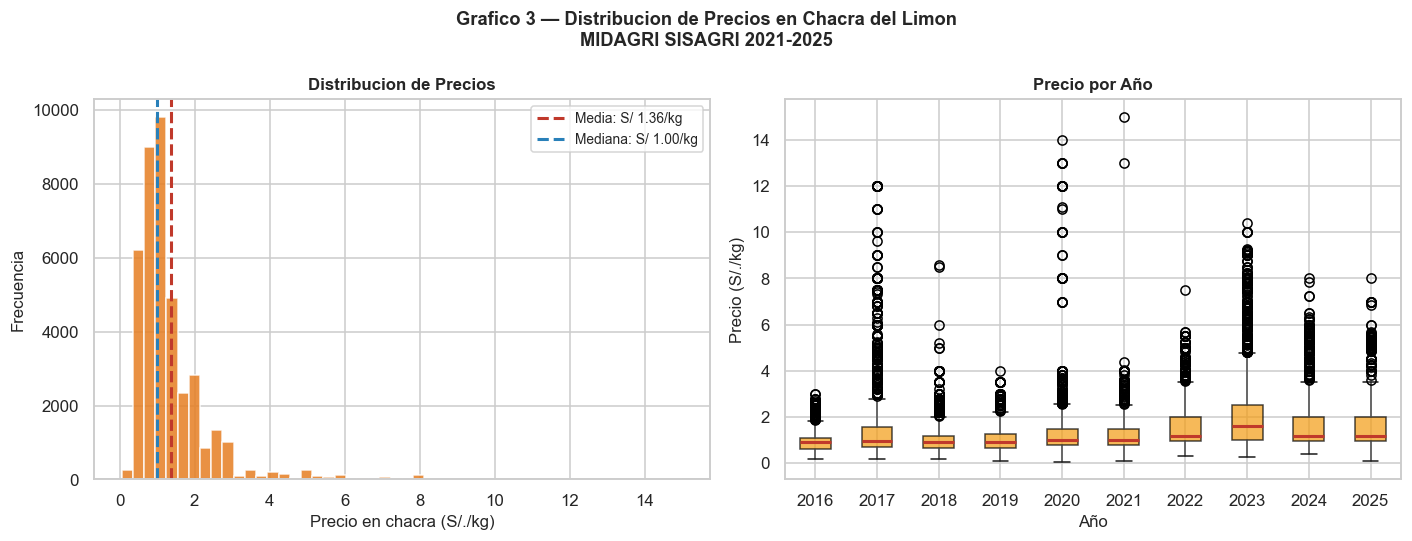

Guardado: pipeline/output/03_eda/act03_midagri_g3_precio_dist.png
Precio medio: S/ 1.36/kg
Precio mediana: S/ 1.00/kg
Precio max: S/ 15.00/kg
Precio min: S/ 0.05/kg
Outliers extremos (>P99 = S/6.00): 389 registros


In [5]:
precios = df_limon['MTO_PRECCHAC (S/ x kg)'].dropna()
precios = precios[precios > 0]  # eliminar ceros para el analisis

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(precios, bins=50, color='#e67e22', edgecolor='white', alpha=0.85)
axes[0].axvline(precios.mean(), color='#c0392b', linestyle='--', linewidth=2,
                label=f'Media: S/ {precios.mean():.2f}/kg')
axes[0].axvline(precios.median(), color='#2980b9', linestyle='--', linewidth=2,
                label=f'Mediana: S/ {precios.median():.2f}/kg')
axes[0].set_xlabel('Precio en chacra (S/./kg)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribucion de Precios', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Boxplot por año
df_limon['anho_str'] = df_limon['anho'].astype(str)
df_limon[df_limon['MTO_PRECCHAC (S/ x kg)'] > 0].boxplot(
    column='MTO_PRECCHAC (S/ x kg)', by='anho_str', ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor='#f39c12', alpha=0.7),
    medianprops=dict(color='#c0392b', linewidth=2)
)
axes[1].set_xlabel('Año', fontsize=11)
axes[1].set_ylabel('Precio (S/./kg)', fontsize=11)
axes[1].set_title('Precio por Año', fontsize=11, fontweight='bold')
plt.suptitle('Grafico 3 — Distribucion de Precios en Chacra del Limon\n'
             'MIDAGRI SISAGRI 2021-2025', fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g3_precio_dist.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Precio medio: S/ {precios.mean():.2f}/kg')
print(f'Precio mediana: S/ {precios.median():.2f}/kg')
print(f'Precio max: S/ {precios.max():.2f}/kg')
print(f'Precio min: S/ {precios.min():.2f}/kg')
q99 = precios.quantile(0.99)
outliers = (precios > q99).sum()
print(f'Outliers extremos (>P99 = S/{q99:.2f}): {outliers} registros')


### Interpretacion

**Que muestra:** La distribucion del precio en chacra del limon. Si la media es mayor que la mediana, la distribucion esta sesgada a la derecha (hay precios extremadamente altos que distorsionan el promedio).

**Implicacion para el pipeline:** Los precios extremos (outliers) se trataran en la Actividad 5 usando el metodo IQR. El boxplot por año permite ver si los precios han subido o bajado en el periodo de estudio.

**Implicacion para el modelo:** El precio en chacra es una variable de entrada del LSTM-Attention. Una distribucion muy sesgada requiere transformacion (log o escalado robusto) para que el modelo no sea dominado por los valores extremos.


## 3.4 Grafico 4 — Correlacion produccion vs. precio


Correlacion de Pearson produccion vs precio: -0.304


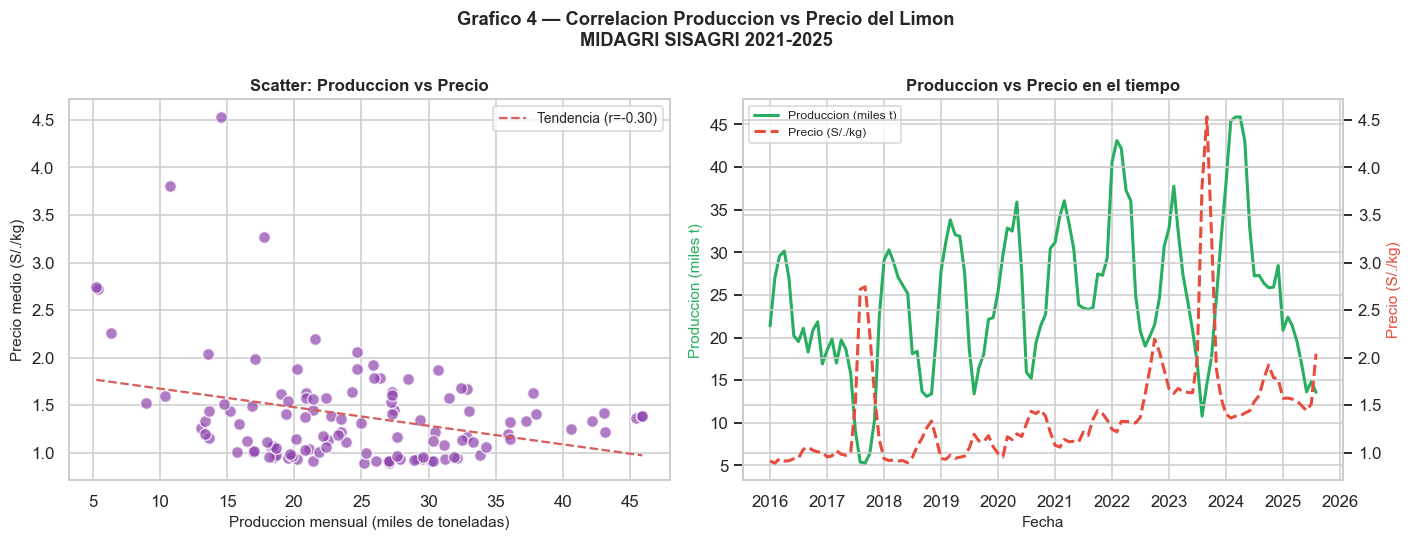

Guardado: pipeline/output/03_eda/act03_midagri_g4_prod_vs_precio.png


In [6]:
# Agregar a nivel mensual nacional
mensual = df_limon.groupby('fecha').agg(
    produccion=('PRODUCCION(t)', 'sum'),
    precio=('MTO_PRECCHAC (S/ x kg)', 'mean')
).reset_index()
mensual = mensual[mensual['precio'] > 0]

corr = mensual['produccion'].corr(mensual['precio'])
print(f'Correlacion de Pearson produccion vs precio: {corr:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(mensual['produccion']/1e3, mensual['precio'],
                alpha=0.7, color='#8e44ad', edgecolors='white', s=60)
# Linea de tendencia
z = np.polyfit(mensual['produccion']/1e3, mensual['precio'], 1)
p = np.poly1d(z)
x_line = np.linspace(mensual['produccion'].min()/1e3, mensual['produccion'].max()/1e3, 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=1.5, label=f'Tendencia (r={corr:.2f})')
axes[0].set_xlabel('Produccion mensual (miles de toneladas)', fontsize=10)
axes[0].set_ylabel('Precio medio (S/./kg)', fontsize=10)
axes[0].set_title('Scatter: Produccion vs Precio', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Doble eje temporal
ax2 = axes[1].twinx()
axes[1].plot(mensual['fecha'], mensual['produccion']/1e3,
             color='#27ae60', linewidth=2, label='Produccion (miles t)')
ax2.plot(mensual['fecha'], mensual['precio'],
         color='#e74c3c', linewidth=2, linestyle='--', label='Precio (S/./kg)')
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('Produccion (miles t)', fontsize=10, color='#27ae60')
ax2.set_ylabel('Precio (S/./kg)', fontsize=10, color='#e74c3c')
axes[1].set_title('Produccion vs Precio en el tiempo', fontsize=11, fontweight='bold')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

plt.suptitle('Grafico 4 — Correlacion Produccion vs Precio del Limon\n'
             'MIDAGRI SISAGRI 2021-2025', fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g4_prod_vs_precio.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La relacion entre produccion mensual y precio en chacra. Una correlacion negativa confirma la ley de oferta/demanda: cuando hay mas produccion, el precio baja. Una correlacion positiva indicaria que ambas suben juntas (posible efecto de demanda).

**Implicacion para el pipeline:** Si la correlacion es fuerte (|r| > 0.5), incluir el precio como variable de entrada del modelo puede generar multicolinealidad con la variable objetivo (produccion). Se evaluara en la Actividad 9.

**Implicacion para el modelo:** El LSTM-Attention puede aprender esta relacion implicita si se incluyen ambas variables. Sin embargo, si el objetivo es predecir produccion, el precio puede ser una variable de salida adicional en lugar de entrada.


## 3.5 Grafico 5 — Estacionalidad mensual de la produccion


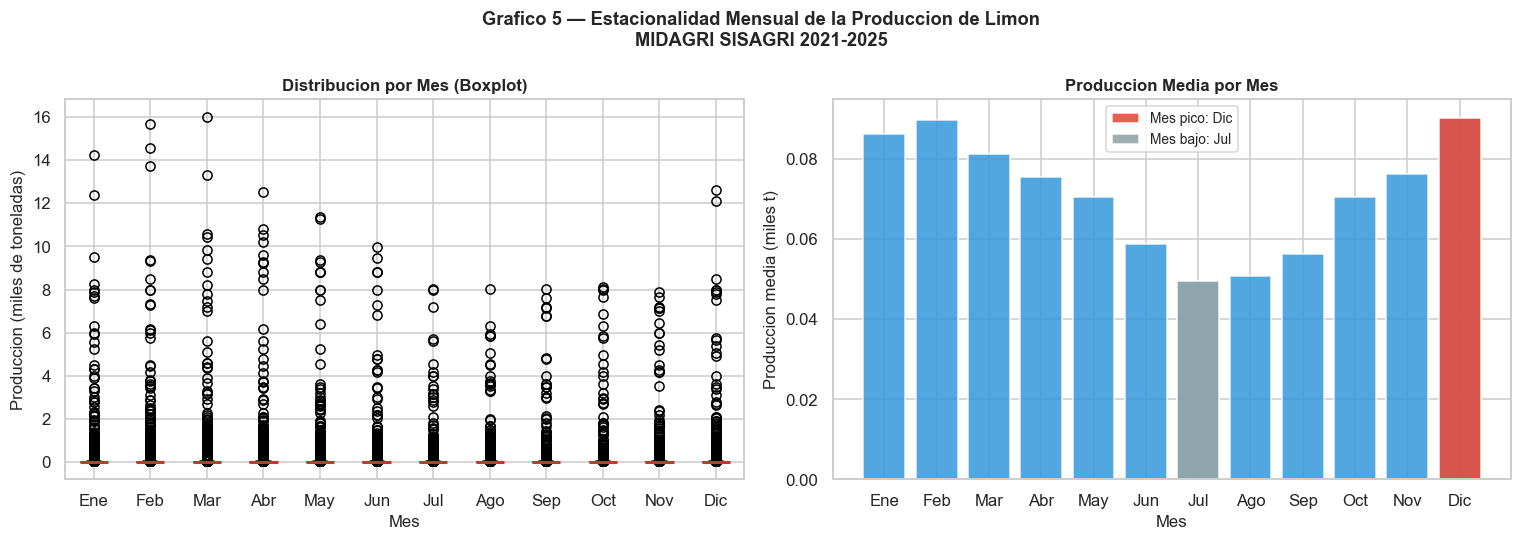

Guardado: pipeline/output/03_eda/act03_midagri_g5_estacionalidad.png
Mes de mayor produccion: Dic (mes 12)
Mes de menor produccion: Jul (mes 7)


In [7]:
df_limon['mes_num'] = df_limon['mes'].astype(int)
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por mes
data_boxplot = [df_limon[df_limon['mes_num']==m]['PRODUCCION(t)'].values / 1e3
                for m in range(1, 13)]
bp = axes[0].boxplot(data_boxplot, labels=meses_nombres, patch_artist=True,
                     medianprops=dict(color='#c0392b', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)
axes[0].set_xlabel('Mes', fontsize=11)
axes[0].set_ylabel('Produccion (miles de toneladas)', fontsize=11)
axes[0].set_title('Distribucion por Mes (Boxplot)', fontsize=11, fontweight='bold')

# Media mensual
media_mes = df_limon.groupby('mes_num')['PRODUCCION(t)'].mean() / 1e3
axes[1].bar(range(1, 13), [media_mes.get(m, 0) for m in range(1, 13)],
            color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses_nombres)
axes[1].set_xlabel('Mes', fontsize=11)
axes[1].set_ylabel('Produccion media (miles t)', fontsize=11)
axes[1].set_title('Produccion Media por Mes', fontsize=11, fontweight='bold')

# Marcar mes de mayor y menor produccion
mes_max = media_mes.idxmax()
mes_min = media_mes.idxmin()
axes[1].bar(mes_max, media_mes[mes_max], color='#e74c3c', edgecolor='white', alpha=0.9,
            label=f'Mes pico: {meses_nombres[mes_max-1]}')
axes[1].bar(mes_min, media_mes[mes_min], color='#95a5a6', edgecolor='white', alpha=0.9,
            label=f'Mes bajo: {meses_nombres[mes_min-1]}')
axes[1].legend(fontsize=9)

plt.suptitle('Grafico 5 — Estacionalidad Mensual de la Produccion de Limon\n'
             'MIDAGRI SISAGRI 2021-2025', fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_midagri_g5_estacionalidad.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print(f'Mes de mayor produccion: {meses_nombres[mes_max-1]} (mes {mes_max})')
print(f'Mes de menor produccion: {meses_nombres[mes_min-1]} (mes {mes_min})')


### Interpretacion

**Que muestra:** El patron estacional de la produccion de limon. El boxplot muestra la variabilidad dentro de cada mes entre diferentes años, y el grafico de barras muestra el promedio historico por mes.

**Implicacion para el pipeline:** El mes de mayor produccion y el de menor son puntos de referencia para validar el modelo. La estacionalidad clara justifica incluir variables ciclicas (month_sin/cos) en la Fase 2.

**Implicacion para el modelo:** Un modelo que no capture la estacionalidad cometera errores sistematicos en los meses de pico y valle. El LSTM-Attention aprendera este patron de la secuencia temporal, pero la codificacion ciclica lo reforzara explicitamente.


## Exportacion de estadisticas MIDAGRI


In [8]:
stats = df_limon[['PRODUCCION(t)','MTO_PRECCHAC (S/ x kg)']].describe().round(2)
print('Estadisticas descriptivas LIMON:')
print(stats.to_string())
stats.to_csv(OUTPUT['eda'] + 'act03_midagri_stats.csv')
print()
print('[ACTIVIDAD 3 - MIDAGRI] COMPLETADA.')
print('Siguiente: pipeline/fuentes/indeci/actividad_03_eda_indeci.ipynb')


Estadisticas descriptivas LIMON:
       PRODUCCION(t)  MTO_PRECCHAC (S/ x kg)
count       40284.00                40284.00
mean           71.03                    1.36
std           520.60                    1.08
min             0.02                    0.05
25%             2.00                    0.80
50%             5.00                    1.00
75%            15.00                    1.55
max         16010.00                   15.00

[ACTIVIDAD 3 - MIDAGRI] COMPLETADA.
Siguiente: pipeline/fuentes/indeci/actividad_03_eda_indeci.ipynb
